In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Fig 1. Data examples (Validation of the experiment and intro to the problem)
A. Short gene. Dbp or Nr1d1. Left: Pro-seq. Right: RNA-seq (Koike). Indicate phases

B. Long gene. Bmal1 or Npas2

C. Best example. ‘Essra’?

D. Eventually the phase relationship of Pro-seq compared to RNA-seq over all genes.

E. Simple transport model. Observation that phase is not constant along the transcript. Motivate the KF.


In [7]:
bin_size = 1000

# get data
time_points = np.arange(0, 48, 4).tolist()

# infiles
infile_proseq = f'../results/GRCm38/binned_norm_coverage/expression_tables/bin_expression_table_bin{bin_size}bp.csv'
infile_rnaseq = f'~/RNAseq/results/Koike_Science_2012/star/binned_norm_coverage/expression_tables/bin_expression_table_bin100bp.csv'
infile_gtf = f'../resources/genome/GRCm38/gene_protein_coding.gtf'

# read data
proseq = pd.read_csv(infile_proseq, sep='\t')
proseq.drop('strand', axis=1, inplace=True)
rnaseq = pd.read_csv(infile_rnaseq, sep='\t')
# flip strands of rnaseq
rnaseq.columns = [col[:-1] + ('+' if col[-1]=='-' else '-') for col in rnaseq.columns]
rnaseq.columns = proseq.columns
genes = pd.read_csv(infile_gtf, sep='\t', comment='#', header=None)

samples = proseq.columns.tolist()[3:]
strand_idx = {'+': [col[-1]=='+' for col in proseq.columns], '-': [col[-1]=='-' for col in proseq.columns]}

# parse gtf and extract atributes
genes.columns = ['chr', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute']
attributes = ['gene_id', 'gene_type', 'gene_name', 'level','tag']
for attribute in attributes:
    if attribute=='level':
        genes[attribute] = genes['attribute'].str.extract(attribute + ' (.*?);')
    else:
        genes[attribute] = genes['attribute'].str.extract(attribute + ' "(.*?)"')
# drop attribute column and set gene_id as index
genes.drop('attribute', axis=1, inplace=True)
genes.set_index('gene_id', inplace=True)


chr7 45705088 45710203 +
chr11 98767932 98775333 -
chr7 113207465 113314126 +
chr5 76209868 76304792 -
chr5 90460897 90476602 +


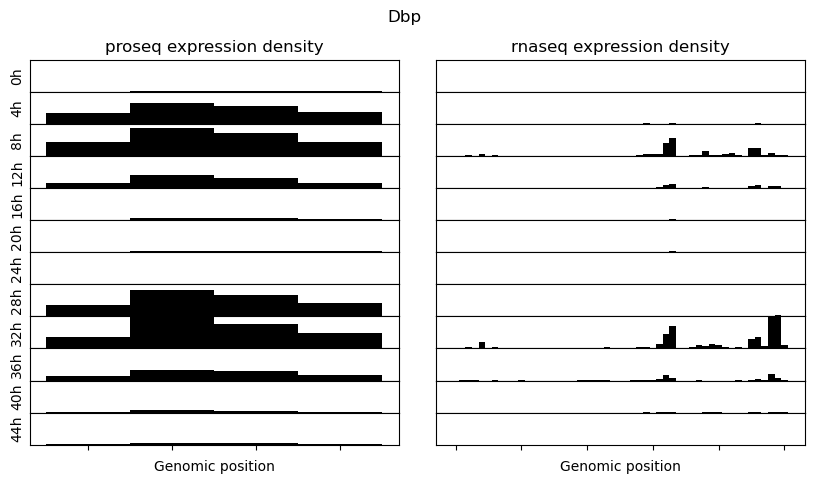

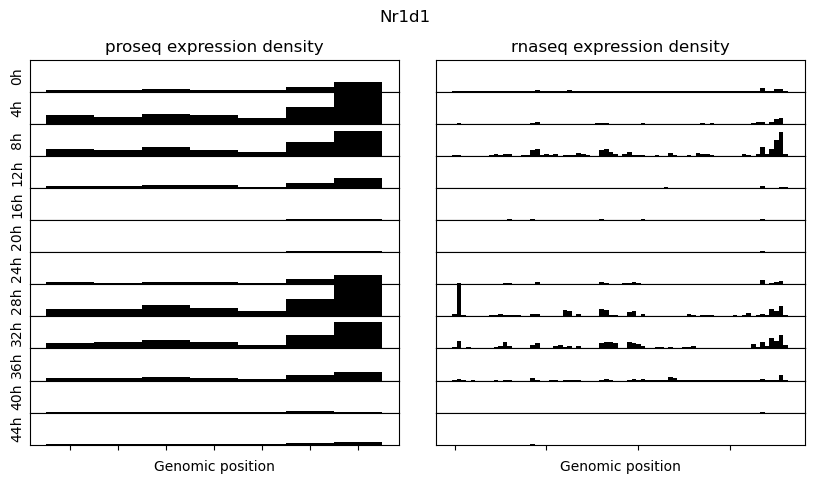

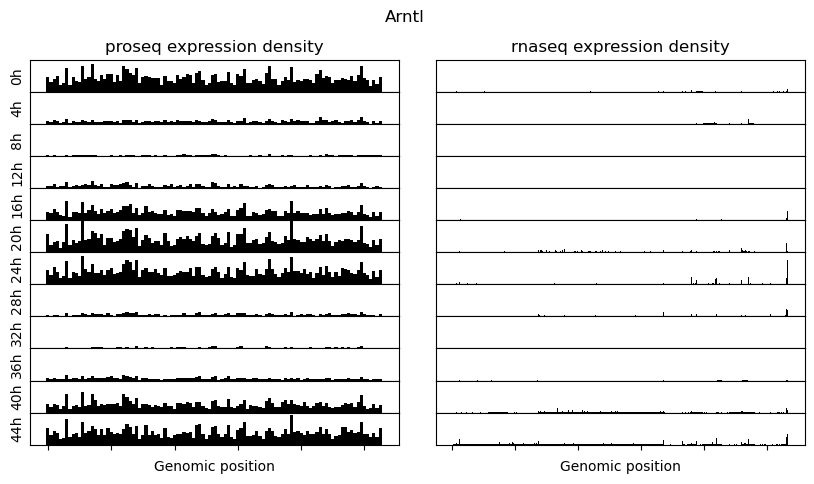

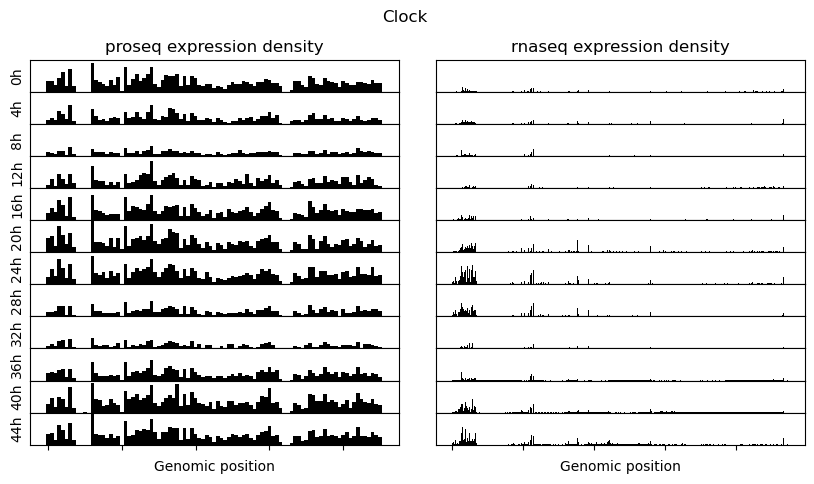

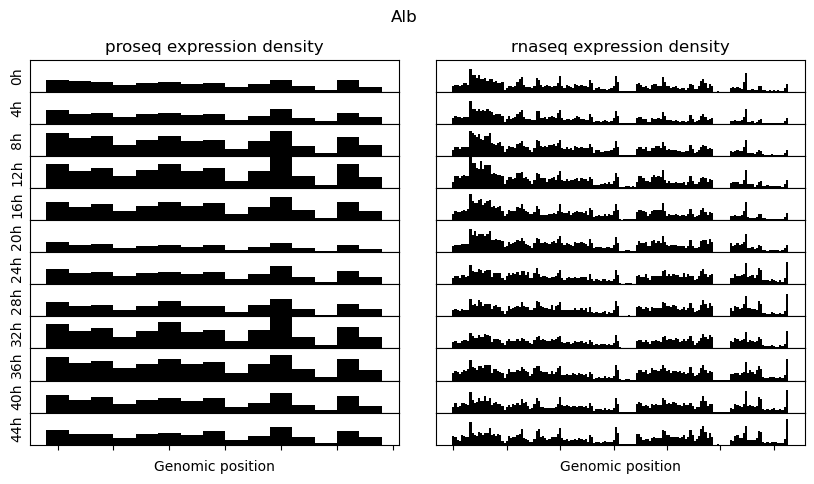

In [21]:
My_genes = ['Dbp','Nr1d1','Arntl','Clock','Alb']

for my_gene in My_genes:
    coords = genes.loc[genes.gene_name == my_gene,['chr','start','end','strand']].values

    for coord in coords:
        chr = coord[0]
        start = coord[1]
        end = coord[2]
        strand = coord[3]
        print(chr,start,end,strand)
        gene_exp = {}
        # get data
        gene_exp['proseq'] = proseq.loc[(proseq.chr == chr) & (proseq.start >= start) & (proseq.end <= end),strand_idx[strand]].values
        gene_exp['rnaseq'] = rnaseq.loc[(rnaseq.chr == chr) & (rnaseq.start >= start) & (rnaseq.end <= end),strand_idx[strand]].values
        
        # replace nan with 0 and make x
        x = {}
        ylim = {}
        for k in gene_exp.keys():
            gene_exp[k] = np.nan_to_num(gene_exp[k])
            x[k] = range(gene_exp[k].shape[0])
            ylim[k] = [1,.95*gene_exp[k].max()]

        # plot
        fig, axes = plt.subplots(ncols=2,nrows=len(time_points), figsize=(10,5), sharex=False, sharey=False)
        for i,t in enumerate(time_points):
            for j,k in enumerate(['proseq','rnaseq']):
                ax = axes[i,j]
                ax.bar(x=x[k], height=gene_exp[k][:,i], width=1, color='k')
                ax.set_ylim(ylim[k])
                #ax.set_yscale('log')
                ax.set_xticks([])
                ax.set_yticks([])
                if t == time_points[0]:
                    ax.set_title(f"{k} expression density")
                if t == time_points[-1]:
                    ax.set_xlabel('Genomic position')
                if (k == 'proseq'):
                    ax.set_ylabel(f'{t}h')
        fig.suptitle(my_gene)
        fig.subplots_adjust(wspace=.1, hspace=0)

    
        #ax.set_title(my_gene)
        #ax.set_xlabel('Genomic position')
        #ax.set_ylabel('Mean coverage')
        #ax.legend()
        #plt.show()
    